In [5]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys

scripts_dir = (Path.cwd() / ".." / "scripts").resolve()
sys.path.append(str(scripts_dir))

from config import final_data_path

# Config
final_data_path = Path(final_data_path)
results_dir = final_data_path / "modeling_results"

In [6]:
rf_df = pd.read_csv(results_dir / "rf/rf_subsampled_summary.csv", index_col="layer")
fm_df = pd.read_csv(results_dir / "fm/fm_subsampled_summary.csv", index_col="layer")

rf_df["model"] = "RF"
fm_df["model"] = "TabPFN"

print(f"RF: {rf_df.shape}")
print(f"FM: {fm_df.shape}")

# Diagnostic -- check whether the two files actually use the same layer names
print("\nRF layer names: ", list(rf_df.index))
print("FM layer names: ", list(fm_df.index))

RF: (4, 10)
FM: (4, 11)

RF layer names:  ['layer_a_bts_subsampled', 'layer_b_bts_meteostat_subsampled', 'layer_c_bts_gdelt_subsampled', 'layer_d_bts_meteostat_gdelt_subsampled']
FM layer names:  ['layer_a_bts_subsampled', 'layer_b_bts_meteostat_subsampled', 'layer_c_bts_gdelt_subsampled', 'layer_d_bts_meteostat_gdelt_subsampled']


In [7]:
def canonicalize_layer(name: str) -> str:
    name = name.lower()
    has_weather = "meteostat" in name or "weather" in name
    has_gdelt = "gdelt" in name

    if has_weather and has_gdelt:
        return "D: BTS+Weather+GDELT"
    elif has_weather:
        return "B: BTS+Weather"
    elif has_gdelt:
        return "C: BTS+GDELT"
    else:
        return "A: BTS"


rf_df["layer_label"] = rf_df.index.map(canonicalize_layer)
fm_df["layer_label"] = fm_df.index.map(canonicalize_layer)

# Confirm both models produced exactly the same 4 canonical labels before
# combining -- if this print shows a mismatch, the raw names above need a
# closer look rather than trusting the canonicalization blindly
print("RF canonical labels:", sorted(rf_df["layer_label"].unique()))
print("FM canonical labels:", sorted(fm_df["layer_label"].unique()))
assert set(rf_df["layer_label"]) == set(fm_df["layer_label"]), \
    "RF and FM don't cover the same 4 layers -- check raw names above"

RF canonical labels: ['A: BTS', 'B: BTS+Weather', 'C: BTS+GDELT', 'D: BTS+Weather+GDELT']
FM canonical labels: ['A: BTS', 'B: BTS+Weather', 'C: BTS+GDELT', 'D: BTS+Weather+GDELT']


In [8]:
metrics = ["f1", "auc_roc", "auc_pr", "mcc"]

combined_df = pd.concat([
    rf_df.reset_index(drop=True),
    fm_df.reset_index(drop=True),
])

combined_df.to_csv(results_dir / "rf_vs_fm_combined.csv", index=False)
combined_df

,f1,precision,recall,auc_roc,auc_pr,mcc,threshold,oob_score,fit_time_s,model,layer_label,n_estimators,subsample_samples
0,0.403024,0.304799,0.594658,0.649609,0.325637,0.180031,0.346075,0.734498,192.426712,RF,A: BTS,NaN,NaN
1,0.411253,0.348537,0.501493,0.677618,0.358824,0.213101,0.399985,0.769540,223.488845,RF,B: BTS+Weather,NaN,NaN
2,0.398467,0.351278,0.460302,0.671854,0.348997,0.203526,0.411764,0.767127,265.098750,RF,C: BTS+GDELT,NaN,NaN
3,0.409664,0.357471,0.479704,0.681010,0.359228,0.216619,0.400000,0.765270,299.639019,RF,D: BTS+Weather+GDELT,NaN,NaN
0,0.419247,0.303660,0.676911,0.669852,0.353983,0.200835,0.162981,NaN,3083.900461,TabPFN,A: BTS,2.0,20000.0
1,0.426415,0.318575,0.644624,0.679198,0.361439,0.215605,0.173017,NaN,3175.308360,TabPFN,B: BTS+Weather,2.0,20000.0
2,0.419794,0.299555,0.701286,0.670394,0.352490,0.200737,0.156630,NaN,3512.824708,TabPFN,C: BTS+GDELT,2.0,20000.0
3,0.426624,0.314350,0.663658,0.678973,0.359232,0.214654,0.170196,NaN,3638.210267,TabPFN,D: BTS+Weather+GDELT,2.0,20000.0


In [9]:
comparison_table = combined_df.pivot(index="layer_label", columns="model", values=metrics)
comparison_table = comparison_table.reorder_levels([1, 0], axis=1).sort_index(axis=1, level=0)

comparison_table.to_csv(results_dir / "rf_vs_fm_comparison_table.csv")
comparison_table

model                       RF                                  TabPFN  \
                        auc_pr   auc_roc        f1       mcc    auc_pr   
layer_label                                                              
A: BTS                0.325637  0.649609  0.403024  0.180031  0.353983   
B: BTS+Weather        0.358824  0.677618  0.411253  0.213101  0.361439   
C: BTS+GDELT          0.348997  0.671854  0.398467  0.203526  0.352490   
D: BTS+Weather+GDELT  0.359228  0.681010  0.409664  0.216619  0.359232   

model                                               
                       auc_roc        f1       mcc  
layer_label                                         
A: BTS                0.669852  0.419247  0.200835  
B: BTS+Weather        0.679198  0.426415  0.215605  
C: BTS+GDELT          0.670394  0.419794  0.200737  
D: BTS+Weather+GDELT  0.678973  0.426624  0.214654

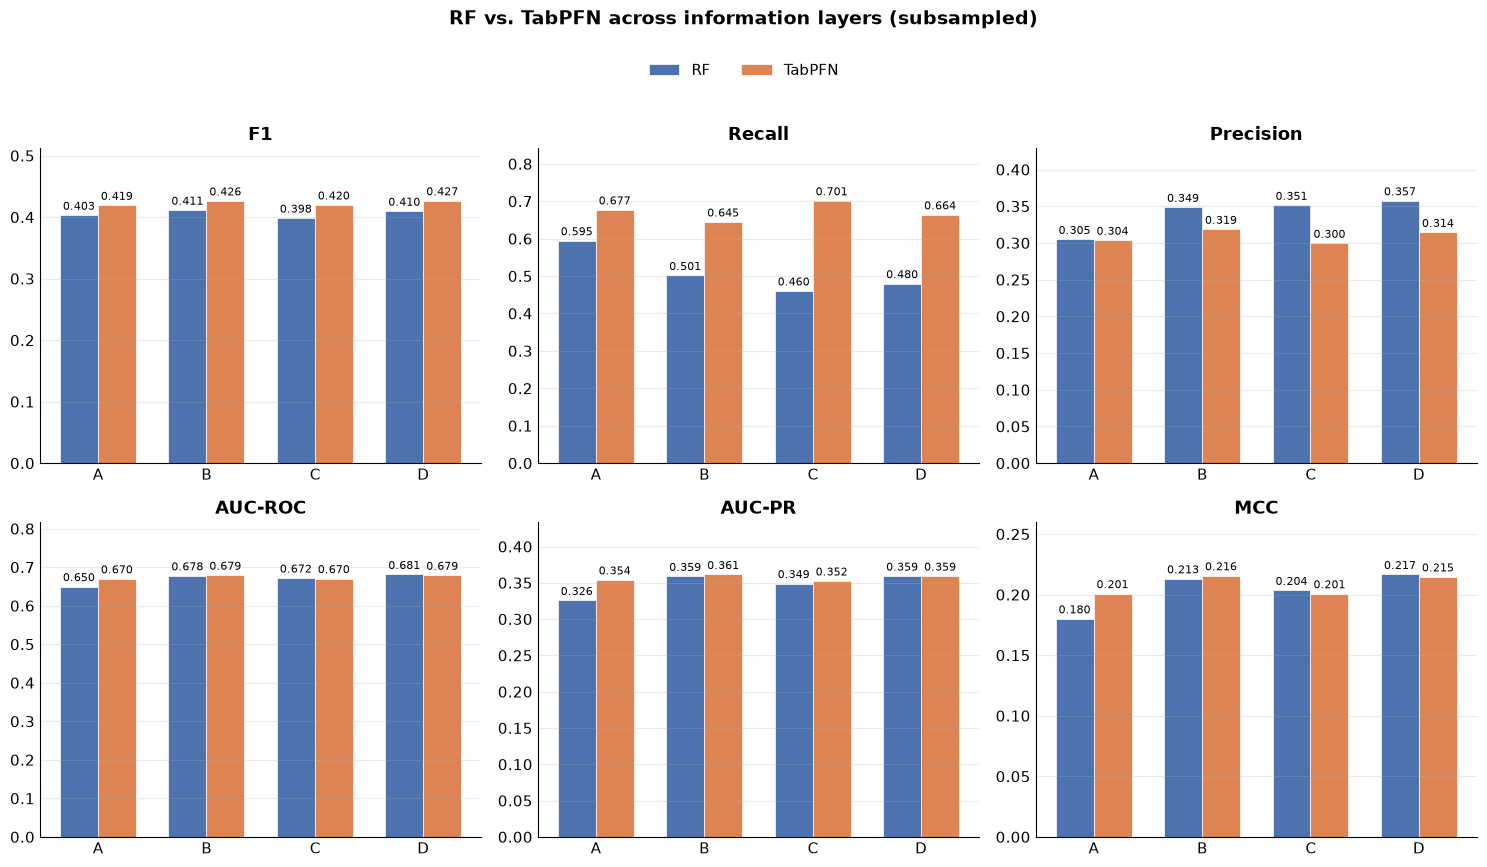

In [12]:
plt.rcParams.update({
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.grid.axis": "y",
})

METRICS = ["f1", "recall", "precision", "auc_roc", "auc_pr", "mcc"]
METRIC_LABELS = {
    "f1": "F1", "recall": "Recall", "precision": "Precision",
    "auc_roc": "AUC-ROC", "auc_pr": "AUC-PR", "mcc": "MCC",
}
MODEL_COLORS = {"RF": "#4C72B0", "TabPFN": "#DD8452"}

layers = sorted(combined_df["layer_label"].unique())  # A, B, C, D order
models = list(combined_df["model"].unique())
x = np.arange(len(layers))
bar_width = 0.35

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, metric in zip(axes, METRICS):
    for i, model in enumerate(models):
        subset = (
            combined_df[combined_df["model"] == model]
            .set_index("layer_label")
            .loc[layers]
        )
        offset = (i - (len(models) - 1) / 2) * bar_width
        bars = ax.bar(
            x + offset, subset[metric], width=bar_width,
            label=model, color=MODEL_COLORS.get(model), edgecolor="white", linewidth=0.5,
        )
        ax.bar_label(bars, fmt="%.3f", padding=2, fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels([l.split(":")[0] for l in layers])  # just "A", "B", "C", "D"
    ax.set_title(METRIC_LABELS[metric], fontweight="bold")
    ax.set_ylim(0, max(combined_df[metric].max() * 1.2, 0.1))
    ax.tick_params(axis="both", length=0)

# Single shared legend instead of one per subplot
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(models), bbox_to_anchor=(0.5, 1.03), frameon=False)

fig.suptitle("RF vs. TabPFN across information layers (subsampled)", y=1.08, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(results_dir / "rf_vs_fm_metrics.png", dpi=150, bbox_inches="tight")
plt.show()